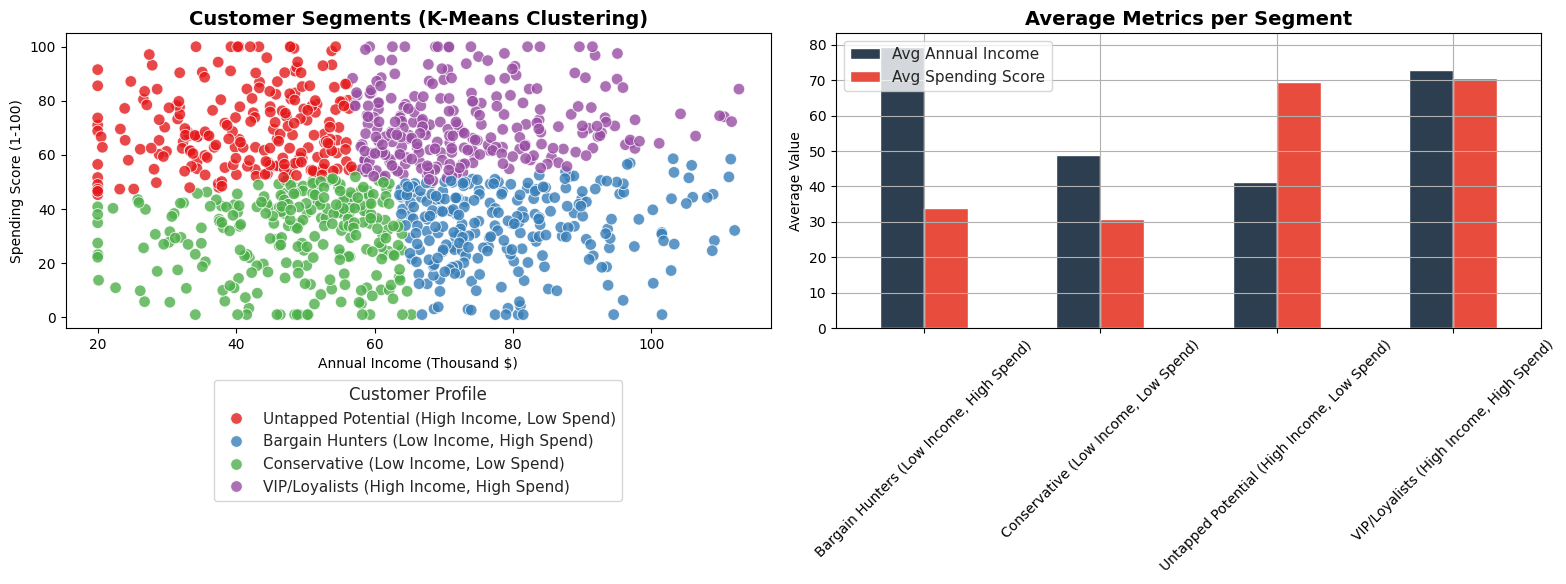

--- CUSTOMER SEGMENTATION SUMMARY ---


,Total Customers
Segment_Name,
"VIP/Loyalists (High Income, High Spend)",262
"Conservative (Low Income, Low Spend)",262
"Bargain Hunters (Low Income, High Spend)",255
"Untapped Potential (High Income, Low Spend)",221


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Generate Realistic E-Commerce Customer Data
np.random.seed(42)
data = {
    'CustomerID': range(1, 1001),
    'Age': np.random.randint(18, 70, size=1000),
    'Annual_Income_k$': np.random.normal(60, 20, size=1000).clip(20, 150),
    'Spending_Score': np.random.normal(50, 25, size=1000).clip(1, 100)
}
df = pd.DataFrame(data)

# 2. Data Preparation for Machine Learning
# We will segment customers based on Income and Spending Score
X = df[['Annual_Income_k$', 'Spending_Score']]

# Standardize the data (crucial for K-Means to work properly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply K-Means Clustering Algorithm
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Customer_Segment'] = kmeans.fit_predict(X_scaled)

# Map numeric clusters to actual business profiles
segment_map = {
    0: 'Bargain Hunters (Low Income, High Spend)',
    1: 'Conservative (Low Income, Low Spend)',
    2: 'VIP/Loyalists (High Income, High Spend)',
    3: 'Untapped Potential (High Income, Low Spend)'
}
df['Segment_Name'] = df['Customer_Segment'].map(segment_map)

# 4. Generate Visualizations (Scatter Plot & Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Chart A: Scatter Plot of Customer Segments
sns.scatterplot(x='Annual_Income_k$', y='Spending_Score', hue='Segment_Name',
                data=df, palette='Set1', ax=axes[0], s=70, alpha=0.8)
axes[0].set_title('Customer Segments (K-Means Clustering)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annual Income (Thousand $)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend(title='Customer Profile', bbox_to_anchor=(0.5, -0.15), loc='upper center')

# Chart B: Average Income & Spend per Segment (Bar Chart)
segment_analysis = df.groupby('Segment_Name')[['Annual_Income_k$', 'Spending_Score']].mean().reset_index()
segment_analysis.plot(x='Segment_Name', y=['Annual_Income_k$', 'Spending_Score'],
                      kind='bar', ax=axes[1], color=['#2c3e50', '#e74c3c'])
axes[1].set_title('Average Metrics per Segment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Value')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Avg Annual Income', 'Avg Spending Score'])

plt.tight_layout()
plt.show()

# Display summary statistics
print("--- CUSTOMER SEGMENTATION SUMMARY ---")
display(df['Segment_Name'].value_counts().to_frame(name='Total Customers'))

Customer Segmentation & Machine Learning Insights

By deploying a K-Means clustering algorithm, the customer base was successfully partitioned into four distinct behavioral segments based on their Annual Income and Spending Score:

VIP/Loyalists (High Income, High Spend): These are the most valuable customers. Recommendation: Implement a premium loyalty tier with exclusive early access to high-margin products to maintain their high retention and spending rate.

Untapped Potential (High Income, Low Spend): These customers have the capital but aren't spending it with us. Recommendation: Deploy targeted remarketing campaigns and personalized product recommendations to capture a larger share of their wallet.

Bargain Hunters (Low Income, High Spend): Highly engaged but price-sensitive. Recommendation: Target them with flash sales, bundle discounts, and clearance items to keep their volume high without eroding premium brand pricing.

Conservative (Low Income, Low Spend): The least engaged segment. Recommendation: Minimize ad spend on this demographic to optimize the overall marketing budget, focusing instead on organic email outreach.